In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
plt.rcParams["figure.figsize"] = (11, 5)

EXPECTED = {
    1: (35040, 11),
    2: [3.17, 4.0, 3.24, 3.31, 3.82, 3.28, 3.6, 3.6, 3.28, 3.78],
    3: 35040,
    4: (-28.9, 37.4),
    5: ["date", "Usage_kWh", "Lagging_Current_Reactive_Power_kVarh",
        "Leading_Current_Reactive_Power_kVarh", "CO2_tCO2_",
        "Lagging_Current_Power_Factor", "Leading_Current_Power_Factor"],
    6: [-12.3, -9.8, -9.7],
}


def _brief(v):
    """Компактное представление ответа для печати."""
    if isinstance(v, (pd.Series, np.ndarray)):
        return list(np.round(np.asarray(v, dtype=object), 4)) if v.dtype == object else v.tolist()
    return v


def check(task, value):
    """Сравнивает ответ с эталоном и печатает вердикт."""
    expected = EXPECTED[task]
    try:
        if value is None or (isinstance(value, type(Ellipsis))):
            print(f"❌ Задание {task}: ответ не заполнен")
            return
        if isinstance(expected, tuple) and not isinstance(value, (list, np.ndarray, pd.Series)):
            ok = tuple(np.round(np.array(value, dtype=float), 6)) == tuple(
                np.round(np.array(expected, dtype=float), 6))
        elif isinstance(expected, list) and isinstance(expected[0], str):
            ok = list(value) == expected
        elif isinstance(expected, list):
            got = np.asarray(pd.Series(value).tolist(), dtype=float)
            ok = got.shape == np.array(expected).shape and np.allclose(got, expected)
        else:
            ok = np.isclose(float(value), float(expected))
    except Exception as e:
        print(f"❌ Задание {task}: не удалось сравнить ответ ({type(e).__name__}: {e})")
        return
    print(f"{'✅' if ok else '❌'} Задание {task}: ваш ответ {_brief(value)}")
    if not ok:
        print(f"   ожидалось: {expected}")


print("Папка с данными найдена:", DATA.exists())
print("Файлы:", [f.name for f in sorted(DATA.iterdir())])

Папка с данными найдена: True
Файлы: ['Steel_Industry.csv', 'температура.txt']


In [4]:
# Задание 1

df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

ans = df_energy.shape

print(ans)

check(1, ans)

(35040, 11)
✅ Задание 1: ваш ответ (35040, 11)


In [5]:
# Задание 2

df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

ans = df_energy["Usage_kWh"].head(10)

print(ans)

check(2, ans)

0    3.17
1    4.00
2    3.24
3    3.31
4    3.82
5    3.28
6    3.60
7    3.60
8    3.28
9    3.78
Name: Usage_kWh, dtype: float64
✅ Задание 2: ваш ответ [3.17, 4.0, 3.24, 3.31, 3.82, 3.28, 3.6, 3.6, 3.28, 3.78]


In [7]:
# Задание 3

temperature = np.loadtxt(DATA / "температура.txt")

ans = len(temperature)

print(ans)

check(3, ans)

35040
✅ Задание 3: ваш ответ 35040


In [8]:
# Задание 4

temperature = np.loadtxt(DATA / "температура.txt")

ans = (temperature.min(), temperature.max())

print(ans)

check(4, ans)

(np.float64(-28.9), np.float64(37.4))
✅ Задание 4: ваш ответ (np.float64(-28.9), np.float64(37.4))


In [9]:
# Задание 5

df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

df_energy = df_energy.drop(
    columns=["NSM", "WeekStatus", "Day_of_week", "Load_Type"]
)

ans = list(df_energy.columns)

print(ans)

check(5, ans)

['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2_', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']
✅ Задание 5: ваш ответ ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2_', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


In [10]:
# Задание 6

df_energy = pd.read_csv(DATA / "Steel_Industry.csv")
temperature = np.loadtxt(DATA / "температура.txt")

df_energy["Temperature_C"] = temperature

ans = df_energy["Temperature_C"].head(3)

print(ans.tolist())

df_energy.head()

check(6, ans)

[-12.3, -9.8, -9.7]
✅ Задание 6: ваш ответ [-12.3, -9.8, -9.7]


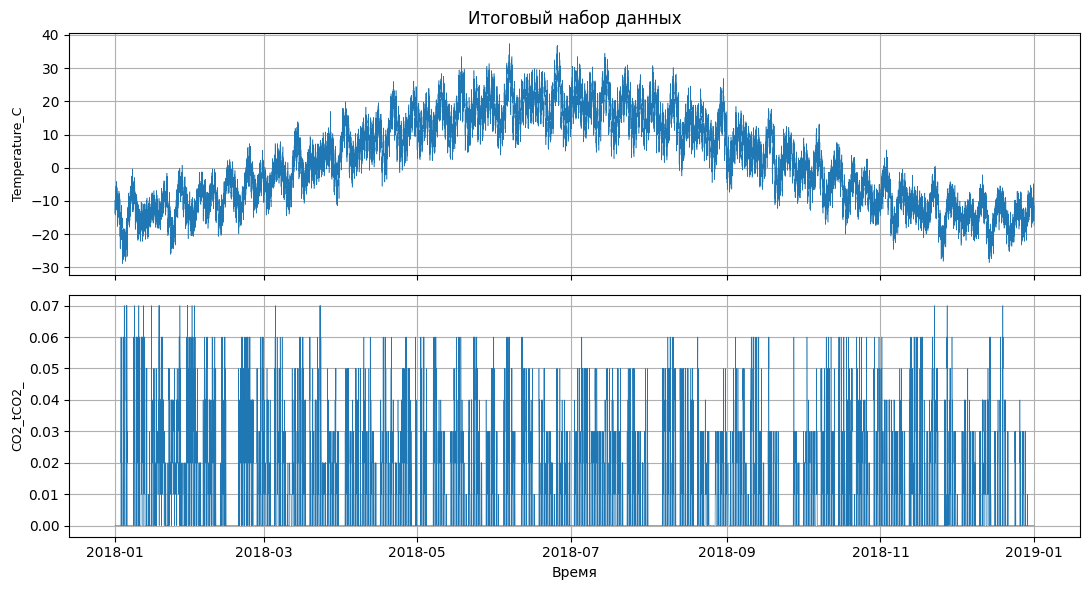

In [11]:
# Заключение — построение графиков

var_plot1 = "Temperature_C"
var_plot2 = "CO2_tCO2_"

df_energy["DateTime"] = pd.to_datetime(
    df_energy["date"],
    format="%d/%m/%Y %H:%M"
)

df_plot = df_energy.sort_values("DateTime")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for ax, name in zip(axes, [var_plot1, var_plot2]):
    ax.plot(df_plot["DateTime"], df_plot[name], linewidth=0.4)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(True)

axes[-1].set_xlabel("Время")
axes[0].set_title("Итоговый набор данных")

plt.tight_layout()
plt.show()